In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = (r"C:\Users\Acer\.cache\kagglehub\datasets\asinow\Different_stores_data_V2.csv")
df = pd.read_csv(file_path, encoding="latin1")

In [2]:
print(df.head())

  invoice_no     invoice_date customer_id  gender  age  category  quantity  \
0    I138884  10/30/2016 9:58     C241288  Female   28  Clothing         5   
1    I317333  10/30/2016 9:58     C111565    Male   21     Shoes         3   
2    I127801  10/30/2016 9:58     C266599    Male   20  Clothing         1   
3    I173702  10/30/2016 9:58     C988172  Female   66     Shoes         5   
4    I337046  10/30/2016 9:59     C189076  Female   53     Books         4   

   selling_price_per_unit  total_profit payment_method region       state  \
0                 1500.40       375.100    Credit Card  South    Kentucky   
1                 1800.51       540.153     Debit Card  South    Kentucky   
2                  300.08         5.020           Cash   West  California   
3                 3000.85       500.425    Credit Card  South     Florida   
4                   60.60        60.600           Cash  South     Florida   

    shopping_mall  
0          Kanyon  
1  Viaport Outlet  
2       

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   invoice_no              99457 non-null  object 
 1   invoice_date            99457 non-null  object 
 2   customer_id             99457 non-null  object 
 3   gender                  99457 non-null  object 
 4   age                     99457 non-null  int64  
 5   category                99457 non-null  object 
 6   quantity                99457 non-null  int64  
 7   selling_price_per_unit  99457 non-null  float64
 8   total_profit            99457 non-null  float64
 9   payment_method          99457 non-null  object 
 10  region                  99457 non-null  object 
 11  state                   99457 non-null  object 
 12  shopping_mall           99457 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 9.9+ MB
None


In [4]:
print(df.describe())

                age      quantity  selling_price_per_unit  total_profit
count  99457.000000  99457.000000            99457.000000  99457.000000
mean      43.427089      3.004424              689.256321    230.751516
std       14.990054      1.415237              941.184567    425.077533
min       18.000000      1.000000                5.230000  -2625.000000
25%       30.000000      2.000000               45.450000     20.920000
50%       43.000000      3.000000              203.300000     94.687500
75%       56.000000      4.000000             1200.320000    300.080000
max       69.000000     15.000000             5250.000000   7087.500000


In [5]:
df = df.drop_duplicates()
df = df.dropna()
df.isnull().sum()

invoice_no                0
invoice_date              0
customer_id               0
gender                    0
age                       0
category                  0
quantity                  0
selling_price_per_unit    0
total_profit              0
payment_method            0
region                    0
state                     0
shopping_mall             0
dtype: int64

In [6]:
import pandas as pd

df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['month'] = df['invoice_date'].dt.to_period('M')
df['revenue'] = df['quantity'] * df['selling_price_per_unit']

In [7]:
customer_revenue = df.groupby('customer_id')['revenue'].sum()
customer_months = df.groupby('customer_id')['month'].nunique()

ltv = (customer_revenue.mean() * customer_months.mean())
print("\nLTV:", ltv)


LTV: 2529.387051489588


In [8]:
order_counts = df.groupby("customer_id").size()
retained_customers = (order_counts > 1).sum()
total_customers = df["customer_id"].nunique()
retention_rate = (retained_customers / total_customers) * 100

print("Retention Rate (доля вернувшихся): %" ,retention_rate)

Retention Rate (доля вернувшихся): % 0.0


In [9]:
churn_rate = 100 - retention_rate
print("Churn Rate (доля ушедших клиентов): %", churn_rate)

Churn Rate (доля ушедших клиентов): % 100.0


In [10]:
aov = df['revenue'].sum() / df['invoice_no'].nunique()
print("\nAOV:", aov)


AOV: 2529.3870514895884


In [11]:
arpu = df['revenue'].sum() / df['customer_id'].nunique()
print("\nARPU:", arpu)


ARPU: 2529.3870514895884


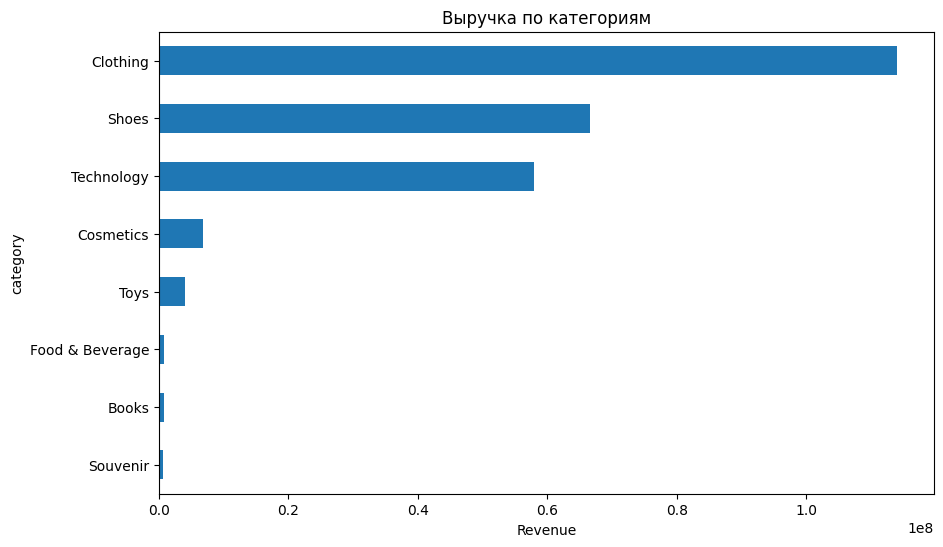

In [12]:
df.groupby('category')['revenue'].sum().sort_values().plot(kind='barh', title='Выручка по категориям', figsize=(10,6))
plt.xlabel("Revenue")
plt.show()

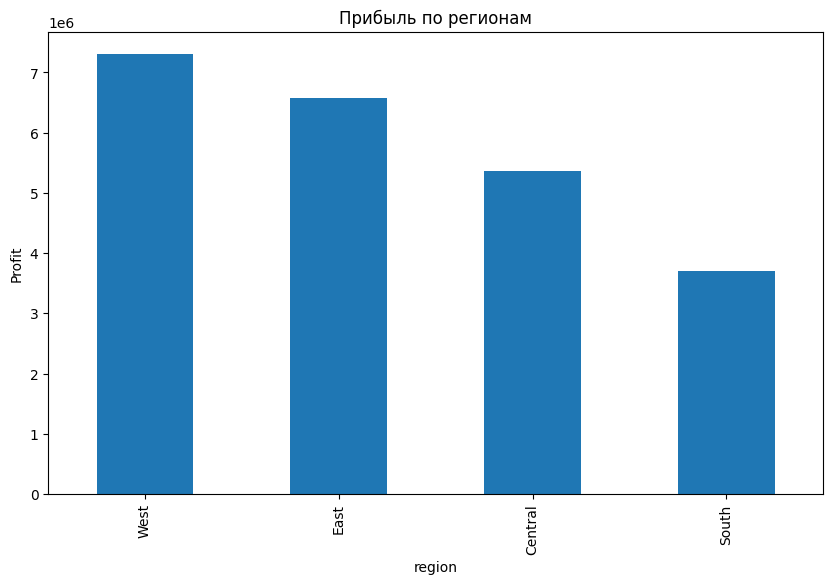

In [13]:
df.groupby('region')['total_profit'].sum().sort_values(ascending=False).plot(kind='bar', title='Прибыль по регионам', figsize=(10,6))
plt.ylabel("Profit")
plt.show()

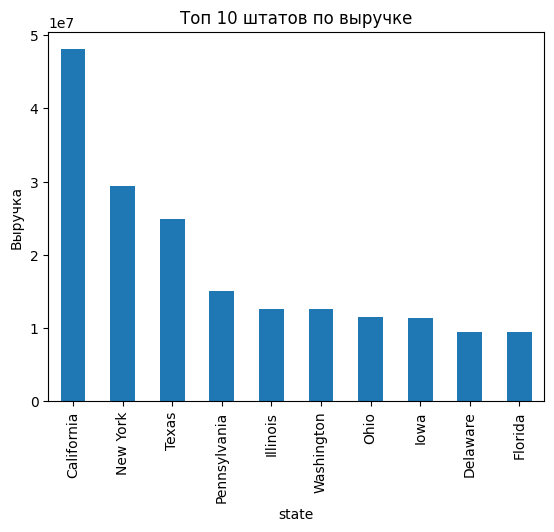

In [14]:
sales_by_state = df.groupby('state')['revenue'].sum().sort_values(ascending=False).head(10)

sales_by_state.plot(kind='bar', title='Топ 10 штатов по выручке')
plt.ylabel('Выручка')
plt.show()

In [15]:
avg_age = df['age'].mean()
print("Средний возраст всех клиентов: ", avg_age)

Средний возраст всех клиентов:  43.42708909377922


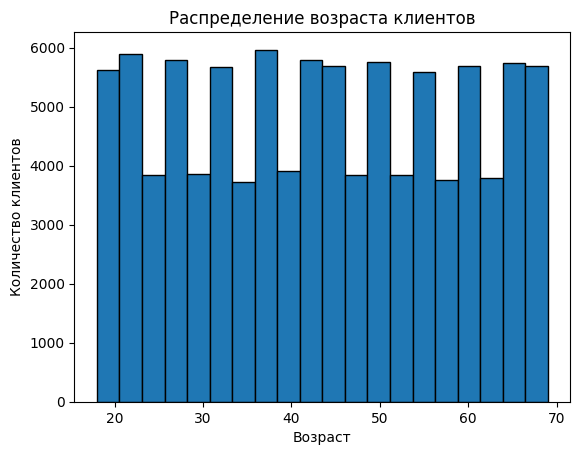

In [16]:
gender_dist = df['gender'].value_counts() * 100

df['age'].plot(kind='hist', bins=20, edgecolor='black')
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество клиентов")
plt.show()

In [17]:
top_customers = df.groupby('customer_id')['quantity'].sum().sort_values(ascending=False).head(5)

print("Топ-5 клиентов по количеству купленных товаров:")
print(top_customers)

Топ-5 клиентов по количеству купленных товаров:
customer_id
C189493    15
C172185    12
C166635    12
C266462    11
C319231    10
Name: quantity, dtype: int64


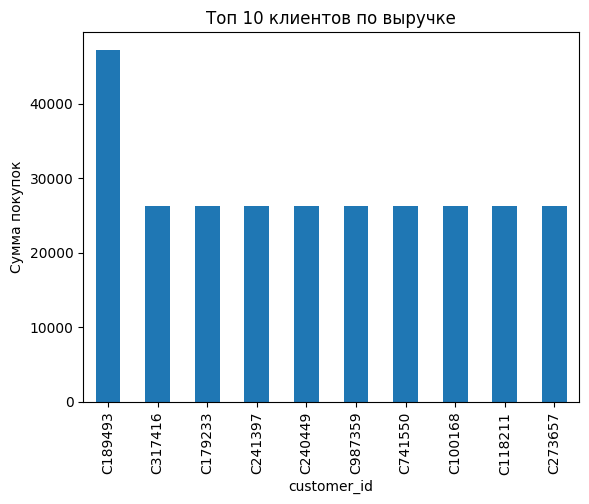

In [18]:
top_customers = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)
top_customers.plot(kind='bar', title='Топ 10 клиентов по выручке')
plt.ylabel('Сумма покупок')
plt.show()

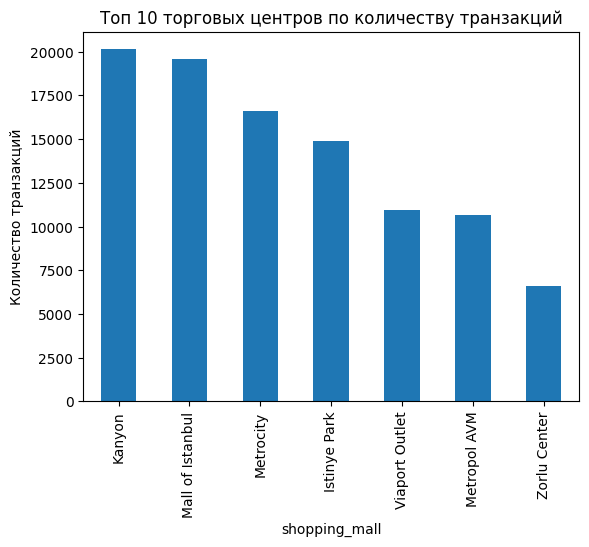

In [19]:
top_malls = df['shopping_mall'].value_counts().head(10)
top_malls.plot(kind='bar', title='Топ 10 торговых центров по количеству транзакций')
plt.ylabel('Количество транзакций')
plt.show()

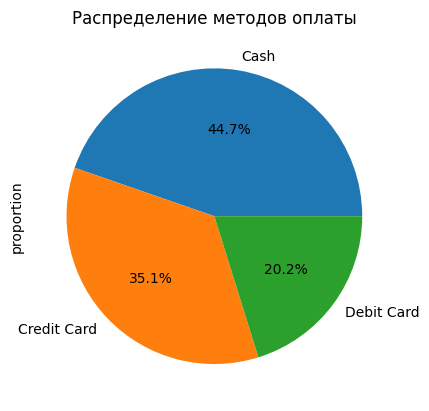

In [20]:
payment_dist = df['payment_method'].value_counts(normalize=True) * 100
payment_dist.plot(kind='pie', autopct='%1.1f%%', title='Распределение методов оплаты')
plt.show()

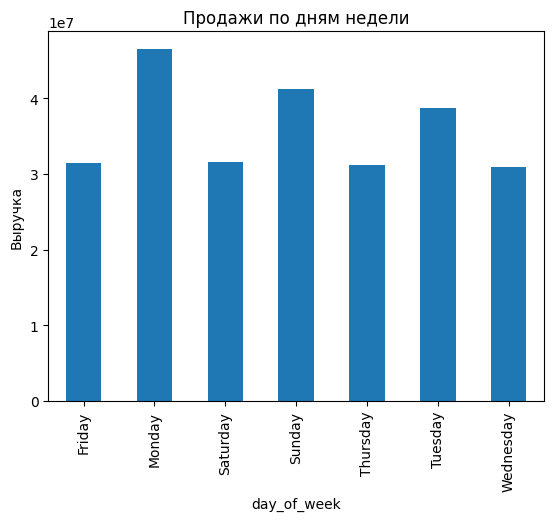

In [21]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'])
df['day_of_week'] = df['invoice_date'].dt.day_name()

weekly_sales = df.groupby('day_of_week')['revenue'].sum()

weekly_sales.plot(kind='bar', title='Продажи по дням недели')
plt.ylabel('Выручка')
plt.show()

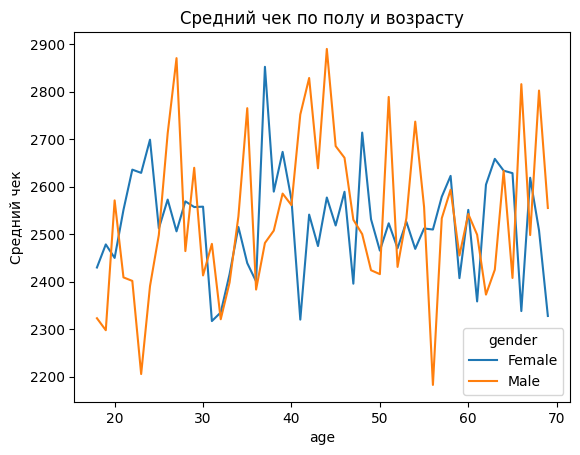

In [22]:
avg_spending = df.groupby(['gender', 'age'])['revenue'].mean().reset_index()
avg_spending_pivot = avg_spending.pivot(index='age', columns='gender', values='revenue')

avg_spending_pivot.plot(kind='line', title='Средний чек по полу и возрасту')
plt.ylabel('Средний чек')
plt.show()

In [23]:
avg_quantity_per_transaction = df['quantity'].mean()
print(f"Среднее количество товаров в одной покупке: ", avg_quantity_per_transaction)

Среднее количество товаров в одной покупке:  3.0044240224418592


<Figure size 1200x600 with 0 Axes>

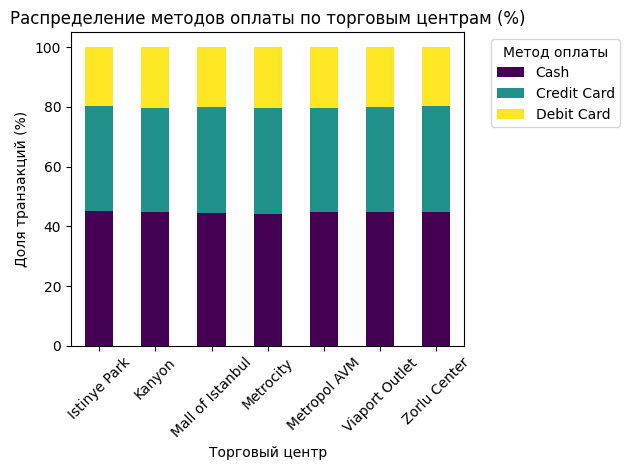

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

payment_by_mall = df.groupby(['shopping_mall', 'payment_method'])['invoice_no'].nunique().unstack().fillna(0)

plt.figure(figsize=(12, 6))
payment_by_mall_percent = payment_by_mall.div(payment_by_mall.sum(axis=1), axis=0) * 100
payment_by_mall_percent.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Распределение методов оплаты по торговым центрам (%)')
plt.ylabel('Доля транзакций (%)')
plt.xlabel('Торговый центр')
plt.legend(title='Метод оплаты', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

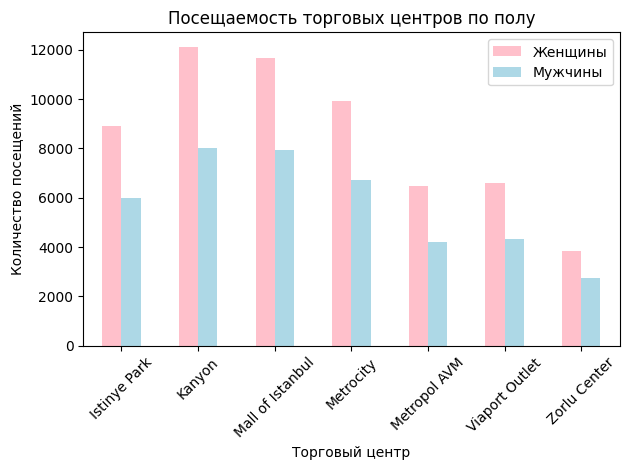

In [30]:
mall_by_gender = df.groupby(['shopping_mall', 'gender'])['invoice_no'].nunique().unstack().fillna(0)

plt.figure(figsize=(12, 6))
mall_by_gender.plot(kind='bar', color=['pink', 'lightblue'])
plt.title('Посещаемость торговых центров по полу')
plt.ylabel('Количество посещений')
plt.xlabel('Торговый центр')
plt.legend(['Женщины', 'Мужчины'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
top_customer_id = df.groupby('customer_id')['revenue'].sum().idxmax()
top_customer_data = df[df['customer_id'] == top_customer_id]

print(f"ID клиента: {top_customer_id}")
print(f"Общая выручка: ${top_customer_data['revenue'].sum():,.2f}")
print(f"Количество покупок: {top_customer_data['invoice_no'].nunique()}")
print(f"Период активности: {top_customer_data['invoice_date'].min().date()} - {top_customer_data['invoice_date'].max().date()}")

print("\nЧастота покупок по категориям:")
print(top_customer_data['category'].value_counts().to_string())

print("\nРегион и штат:")
print(f"Основной регион: {top_customer_data['region']}")
print(f"Основной штат: {top_customer_data['state']}")

print("\nТорговые центры:")
print(top_customer_data['shopping_mall'].value_counts().to_string())

print("\nМетоды оплаты:")
print(top_customer_data['payment_method'].value_counts().to_string())

ID клиента: C189493
Общая выручка: $47,250.00
Количество покупок: 1
Период активности: 2016-10-30 - 2016-10-30

Частота покупок по категориям:
category
Technology    1

Регион и штат:
Основной регион: 100    Central
Name: region, dtype: object
Основной штат: 100    Illinois
Name: state, dtype: object

Торговые центры:
shopping_mall
Viaport Outlet    1

Методы оплаты:
payment_method
Credit Card    1
